<a href="https://colab.research.google.com/github/Stamatics-NumberstoNeurons/assignment2-aryakishor-a/blob/main/Assignment_2_N2N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [111]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [112]:
#code here
class NANDPerceptron:
    def __init__(self):
        self.weights = np.array([-1, -1])
        self.bias = 1.5

    def activation(self, z):
        return (z >= 0).astype(int)

    def predict(self, X):
        z = X @ self.weights + self.bias
        return self.activation(z)


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:** It is because perceptron has a fixed threshhold over which anything is 1, below it anything is 0. It does not work as a gradient like 0.2, 0.7 etc.

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:** As c goes to infinity, if z>0 then cz goes to infinity and σ(cz) to 1. If z < 0 then cz goes to minus infinity and σ(cz) goes 0. Therefore, the sigmoid neuron behaves like a classic perceptron with a hard threshold at z= 0.
Sigmoid is preferred because it is differentiable, and perceptron is a step function. Gradient training can be used in sigmoid. Perceptron can vary too much by slight variation in weights,etc, as it works on 1 or 0 basis.

---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:** The factor is used to make differentiation cleaner. Since the cost contains a squared error term, differentiating it cancels with the 1/2.

For one term, if C = (1/2)(y - a)^2, then

dC/dw = (1/2) * 2(y - a) * d(y - a)/dw

So the 2 cancels:

dC/dw = (y - a) * d(y - a)/dw

Thus, it makes the derivative simpler by removing an extra factor of 2.

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:** Using given values in formula, answer comes as 0.025.
Cost is small, so the network is fairly good. The second example adds more to cost C.

In [113]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

C_val = ((outputs-targets)@(outputs-targets))/(2*outputs.size) # TODO: compute C
print(f'C = {C_val}')

C = 0.024999999999999998


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:** We use a cost function because it gives a smooth measure of how wrong the network is. Accuracy only counts whether the final classification is correct or not,but not how correct it was.
For example, predictions 0.51 and 0.99 may both be classified as 1, so accuracy treats them the same, even though 0.99 is much closer.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:** The function |y - a| has a sharp corner when y=a, so the gradient is undefined at that point. Squared error graph is smooth and differentiable at all points.

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:** The values w=3,b=1 minimise C=0, because it takes squared difference terms which is minimum when the difference in each term is zero.

### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:** dC/dw = 2(w - 3) and dC/db = 4(b - 1).

Starting from (w,b) = (0,0):

Step 1:
dC/dw =2(0 - 3)= -6
dC/db = 4(0 - 1)=-4

w = 0- 0.1(-6) =0.6
b = 0 - 0.1(-4) = 0.4

After step 1, (w,b) = (0.6, 0.4). so C is 6.48.

Step 2:
dC/dw=2(0.6-3) =-4.8
dC/db = 4(0.4- 1)= -2.4

w = 0.6-0.1(-4.8) =1.08
b = 0.4- 0.1(-2.4)= 0.64

After step 2, the parameter vector is (w,b) = (1.08,0.64)

In [114]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2*(w-3)  # TODO
    db = 4*(b-1)  # TODO
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:** With eta = 0.6, the b update overshoots the minimum. Starting from b = 0, the gradient is dC/db = 4(b - 1) = -4. So the first update gives b = 0 - 0.6(-4) = 2.4, which jumps past the optimum b = 1.

Then at b = 2.4, dC/db = 4(2.4 - 1) = 5.6, so b = 2.4 - 0.6(5.6) = -0.96, again jumping to the other side. The values keep oscillating: 0 → 2.4 → -0.96 → 3.744 → -2.8416, and the cost increases.

This shows that if the learning rate is too large, gradient descent may overshoot the minimum and diverge instead of converging. A learning rate should be small enough to move toward the minimum gradually.

In [115]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [116]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
        # TODO: compute z = w.x + b, return sigmoid(z)
        z = self.weights@x+self.bias
        return 1/(1+ np.exp(-z))

    def numerical_gradient(self, x, h=1e-5):
        # TODO: centered difference (f(x+h) - f(x-h)) / 2h
        # return (grad_weights, grad_bias)
        grad_weights = np.zeros_like(self.weights)

        for i in range(len(self.weights)):
            original = self.weights[i]

            self.weights[i] = original + h
            f_plus = self.forward(x)

            self.weights[i] = original - h
            f_minus = self.forward(x)

            grad_weights[i] = (f_plus - f_minus) / (2 * h)

            self.weights[i] = original

        original_bias = self.bias

        self.bias = original_bias + h
        f_plus = self.forward(x)

        self.bias = original_bias - h
        f_minus = self.forward(x)

        grad_bias = (f_plus - f_minus) / (2 * h)

        self.bias = original_bias

        return grad_weights, grad_bias

### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [117]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **Your answer:** The gradient means that if w1 is increased slightly, the neuron output will increase by about 0.149146 times as much as w1. Since the gradient is positive, increasing w1 increases the output for 1,1 input.

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:** The gradient is largest at z = 0. At this point, sigma(0) = 0.5, so sigma'(0) = sigma(0)(1 - sigma(0)) = 0.5(0.5) = 0.25.

As z approaches +infinity, sigma(z) approaches 1, so sigma'(z) approaches 0. As z approaches -infinity, sigma(z) approaches 0, so sigma'(z) also approaches 0.

This is a problem because when the gradient becomes very small, weight updates during gradient descent become tiny. This is the vanishing gradient problem, and it makes learning very slow in thoseregions of the sigmoid.

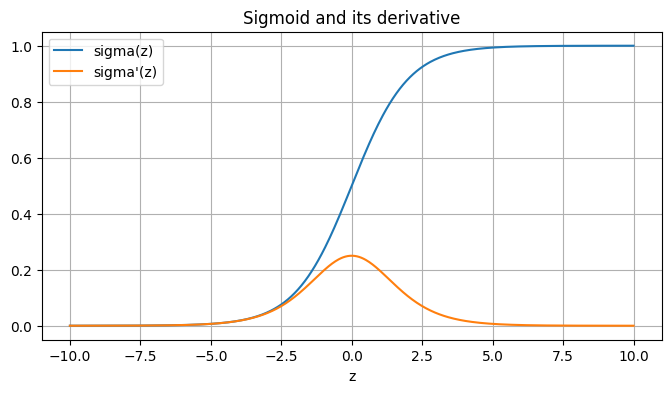

In [118]:
z = np.linspace(-10, 10, 500)

# TODO: compute sigma and sigma_prime
sigma       = 1/(1+np.exp(-z))
sigma_prime = sigma * (1-sigma)

plt.figure(figsize=(8, 4))
# TODO: plot both curves
plt.plot(z,sigma,label='sigma(z)')
plt.plot(z,sigma_prime, label="sigma'(z)")
plt.xlabel('z')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:** The claim is mostly correct. sigma(100z) becomes very steep near z = 0, so it behaves almost like a perceptron step function.
But it is not exactly the same. At z = 0, sigma(100z) = 0.5, while a step function gives 0 or 1 depending on convention. Also near z = 0 it is still smooth, not a hard jump.
So it breaks down near the decision boundary z = 0.

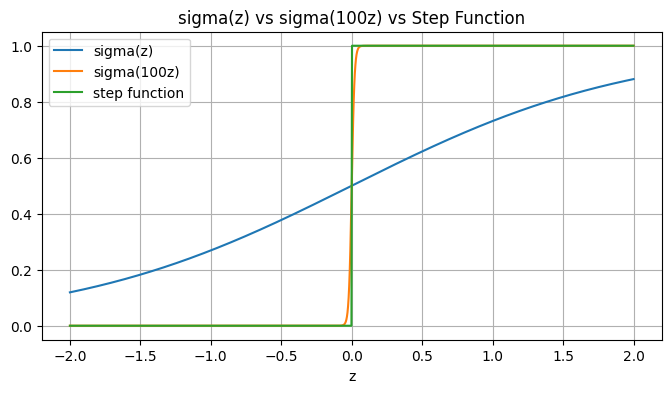

In [119]:
z = np.linspace(-2, 2, 1000)

# TODO: compute sigma(z), sigma(100*z), step function
sigma = 1 / (1 + np.exp(-z))
sigma_100 = 1 / (1 + np.exp(-100 * z))
step = (z >= 0).astype(int)

plt.figure(figsize=(8, 4))
# TODO: plot all three
plt.plot(z, sigma, label='sigma(z)')
plt.plot(z, sigma_100, label='sigma(100z)')
plt.plot(z, step, label='step function')
plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [120]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:** For each training example, the prediction is:
y_hat_i = wx_i + b
The cost function is:
C = (1 / 2n) * Σ(y_hat_i - y_i)^2

Substitute y_hat_i = wx_i + b:
C = (1 / 2n) * Σ(wx_i + b - y_i)^2

For dC/dw:
dC/dw = (1 / 2n) * Σ 2(wx_i + b - y_i) * x_i
So,dC/dw = (1 / n) * Σ(wx_i + b - y_i)x_i

For dC/db,dC/db = (1 / 2n) * Σ 2(wx_i + b - y_i) * 1

So,dC/db = (1 / n) * Σ(wx_i + b - y_i)

These gradients are used to update w and b in gradient descent. After training, w and b become close to 3 and 1, so the model is converging to the correct line.

Final w = 2.9910, b = 1.0256


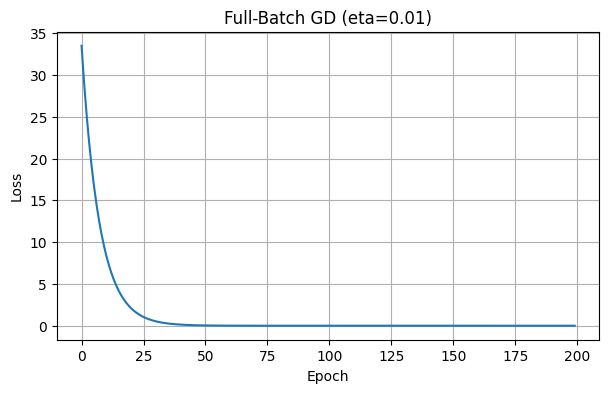

In [121]:
w, b = 0.0, 0.0
eta = 0.01
losses = []

for epoch in range(200):
    # TODO: predictions, loss, gradients, update
    y_pred = w * X_train + b

    # error
    error = y_pred - y_train

    # loss
    loss = (1 / (2 * X_train.size)) * np.sum(error ** 2)
    losses.append(loss)

    # gradients
    dw = (1 / X_train.size) * np.sum(error * X_train)
    db = (1 / X_train.size) * np.sum(error)

    # update
    w = w - eta * dw
    b = b - eta * db


print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:** SGD with batch size 1 uses only one random example for each update, so the gradient is noisy. Because of this, the loss curve may go up and down instead of decreasing smoothly.

Full-batch GD uses all examples, so its gradient is more stable and the loss curve is smoother. SGD is noisier, but it can still move toward the minimum on average.

Final w = 2.9985, b = 1.0046


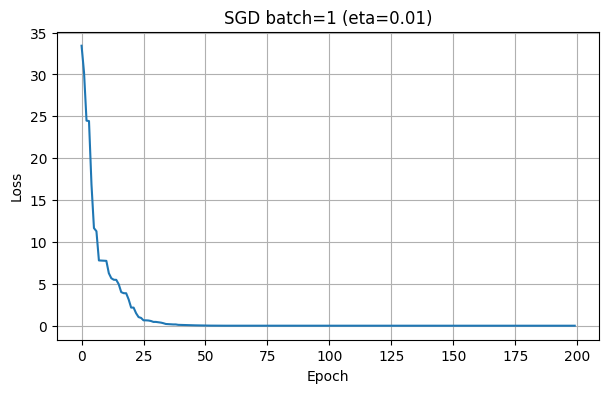

In [122]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []

for epoch in range(200):
    i = np.random.randint(X_train.size)
    x_i = X_train[i]
    y_i = y_train[i]

    y_pred = w * x_i + b
    error = y_pred - y_i

    dw = error * x_i
    db = error

    w = w - eta * dw
    b = b - eta * db

    all_pred = w * X_train + b
    all_error = all_pred - y_train

    loss = (1 / (2 * X_train.size)) * np.sum(all_error ** 2)
    losses_sgd.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:** With eta = 0.5, the learning rate is too large, so the updates overshoot the minimum. From Q5a, the gradients are dC/dw = (1/n)Σ(error*x_i) and dC/db = (1/n)Σ(error). If eta is too large, these gradient values are multiplied by a large step size, causing w and b to jump too far.

Instead of moving gradually toward w = 3 and b = 1, the parameters move past the optimum and the loss increases. Therefore, gradient descent diverges when the learning rate is too large.

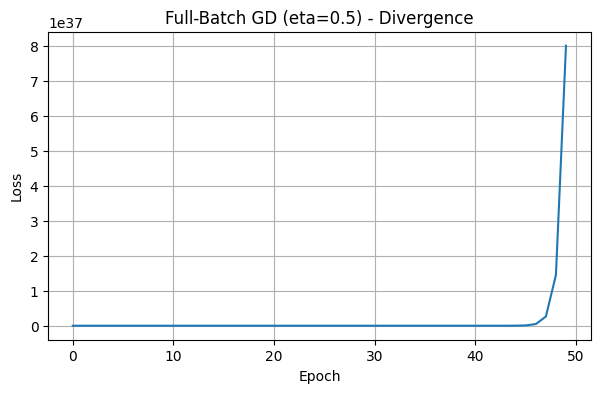

In [123]:
w, b = 0.0, 0.0
eta=0.5
losses_div = []

for epoch in range(50):
    # TODO: full-batch GD with eta=0.5
    y_pred = w * X_train + b
    error = y_pred - y_train

    # full-batch loss
    loss = (1 / (2 * X_train.size)) * np.sum(error ** 2)
    losses_div.append(loss)

    if not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

    # full-batch gradients
    dw = (1 / X_train.size) * np.sum(error * X_train)
    db = (1 / X_train.size) * np.sum(error)

    # update
    w = w - eta * dw
    b = b - eta * db

    if loss is not None and not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:** Since the input is a one-hot vector of length 10,1 position is 1 and all others are 0. Therefore, W@one_hot selects one column of W.
So we can store the 4-bit binary representation of each digit as the corresponding column of W. The bias vector can be all zeros. After thresholding at 0.5, each column directly becomes the required 4-bit output.

In [124]:
# TODO: define W (4x10) and b_enc (4,)
W     = np.array([
    [0,0,0,0,0,0,0,0,1,1],
    [0,0,0,0,1,1,1,1,0,0],
    [0,0,1,1,0,0,1,1,0,0],
    [0,1,0,1,0,1,0,1,0,1]
])  # shape (4, 10)
b_enc = np.zeros(4)  # shape (4,)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:** The update rule v = v - alpha*dC/dv means we move on the curve in the direction where cost decreases.
dC/dv is basically the slope at the current point. If slope is positive, the curve is going up as v increases, so we move left. If slope is negative, we move right.
Alpha decides how big the step is. If alpha is small,movement is slow but safe. If alpha is too large,it can jump over the minimum and keep oscillating.

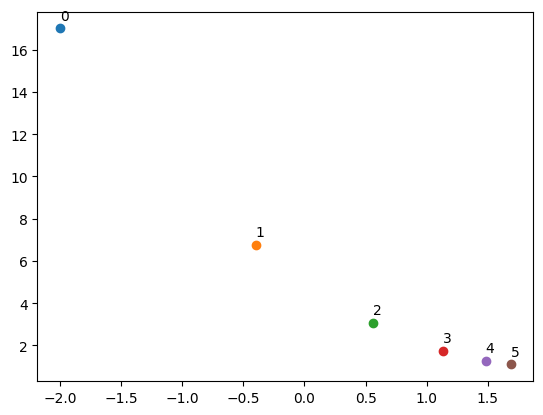

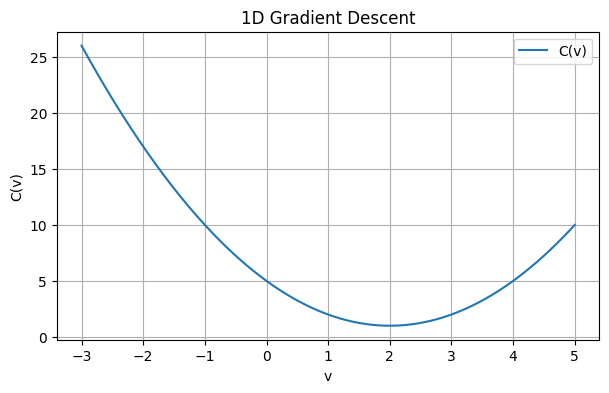

In [125]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

# TODO: run gradient descent steps and annotate on the curve
v = -2
alpha = 0.2
for step in range(6):
    C = (v-2)**2 + 1
    grad = 2*(v-2)
    plt.scatter(v,C)
    plt.text(v,C + 0.4, f'{step}')

    v = v - alpha * grad
plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label='C(v)')
plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:** If we remove all hidden layers and connect 784 inputs directly to 10 outputs, the model becomes a linear classifier. It is basically like multinomial logistic regression.
The accuracy is capped because the model can only learn linear decision boundaries. Real digit images are not separated perfectly by simple straight lines.
This shows why hidden layers are needed. Hidden layers allow the network to learn useful features and nonlinear patterns, like strokes, curves and shapes, instead of only using a direct linear mapping from pixels to outputs.